<a href="https://colab.research.google.com/github/shareotherban/STT-Model/blob/main/STT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("HELLO SPEECH TO TEXT")

HELLO SPEECH TO TEXT


In [ ]:
!git clone https://github.com/Jakobovski/free-spoken-digit-dataset.git

Cloning into 'free-spoken-digit-dataset'...
remote: Enumerating objects: 4260, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 4260 (delta 25), reused 8 (delta 8), pack-reused 4212 (from 1)
Receiving objects: 100% (4260/4260), 30.38 MiB | 24.61 MiB/s, done.
Resolving deltas: 100% (129/129), done.


In [ ]:
import os

#we only tring to train on numbers from 0-9 and it has 3000 recording that it saying it in 3000 diff ways
digit_to_word = {
    '0': 'zero', '1': 'one', '2': 'two', '3': 'three', '4': 'four',
    '5': 'five', '6': 'six', '7': 'seven', '8': 'eight', '9': 'nine'
}

recordings_dir = 'free-spoken-digit-dataset/recordings'
filenames = sorted(os.listdir(recordings_dir))

file_labels = []
for fname in filenames:
    digit = fname.split('_')[0]
    label = digit_to_word[digit]
    file_labels.append((os.path.join(recordings_dir, fname), label))

print(len(file_labels), 'clips found')
print(file_labels[0])

3000 clips found
('free-spoken-digit-dataset/recordings/0_george_0.wav', 'zero')


In [ ]:
import wave
import numpy as np

def load_wav(path):
    with wave.open(path, 'rb') as wf:
        sample_rate = wf.getframerate()
        n_frames = wf.getnframes()
        raw_bytes = wf.readframes(n_frames)
    # These clips are 16-bit PCM, mono -> each sample is a signed 2-byte int
    samples = np.frombuffer(raw_bytes, dtype=np.int16)
    # Normalize int16 range [-32768, 32767] to roughly [-1, 1]
    waveform = samples.astype(np.float32) / 32768.0
    return waveform, sample_rate

wav, sr = load_wav(file_labels[0][0])
print(wav.shape, wav.dtype, sr)

(2384,) float32 8000


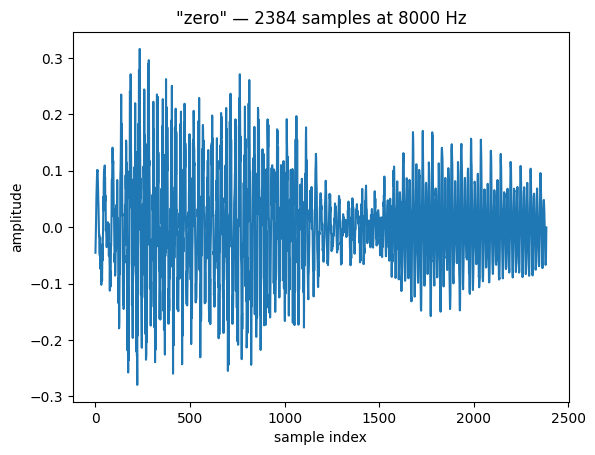

In [ ]:
import matplotlib.pyplot as plt

plt.plot(wav)
plt.title(f'"{file_labels[0][1]}" — {len(wav)} samples at {sr} Hz')
plt.xlabel('sample index')
plt.ylabel('amplitude')
plt.show()

In [ ]:
import random

dataset = []
for path, label in file_labels:
    waveform, sr = load_wav(path)
    dataset.append((waveform, label))

random.seed(42)
random.shuffle(dataset)
# we use 80% of the data to train
split_idx = int(0.8 * len(dataset))
train_set = dataset[:split_idx]
test_set = dataset[split_idx:]

print(f'train: {len(train_set)}, test: {len(test_set)}')
print('example label:', train_set[0][1])

train: 2400, test: 600
example label: eight


In [ ]:
def compute_spectrogram(waveform, sample_rate, frame_ms=25, hop_ms=10):
    frame_len = int(sample_rate * frame_ms / 1000)   # samples per frame
    hop_len = int(sample_rate * hop_ms / 1000)        # samples per step

    window = np.hamming(frame_len)  # taper shape, one fixed math primitive

    n_frames = max(1, 1 + (len(waveform) - frame_len) // hop_len)

    spectrogram = []
    for i in range(n_frames):
        start = i * hop_len
        frame = waveform[start:start + frame_len]
        if len(frame) < frame_len:                     # pad the last frame if short
            frame = np.pad(frame, (0, frame_len - len(frame)))

        windowed = frame * window                       # apply taper
        spectrum = np.fft.rfft(windowed)                 # time -> frequency
        magnitude = np.abs(spectrum)                     # we only care about energy, not phase
        log_magnitude = np.log1p(magnitude)               # log(1+x): compress dynamic range, avoid log(0)

        spectrogram.append(log_magnitude)

    return np.array(spectrogram)  # shape: (n_frames, freq_bins)

(28, 101)


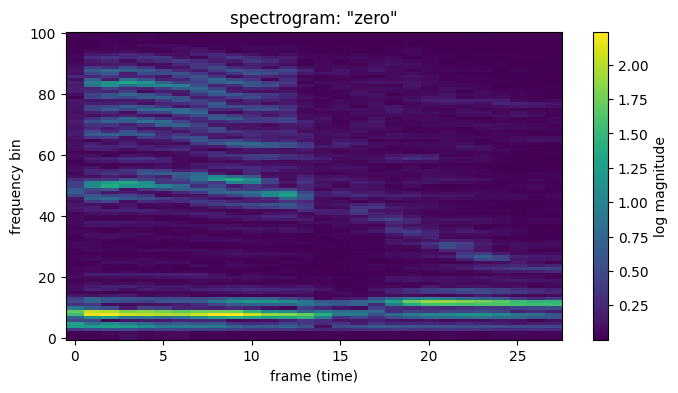

In [ ]:
spec = compute_spectrogram(wav, sr)
print(spec.shape)

plt.figure(figsize=(8, 4))
plt.imshow(spec.T, aspect='auto', origin='lower', cmap='viridis')
plt.xlabel('frame (time)')
plt.ylabel('frequency bin')
plt.title(f'spectrogram: "{file_labels[0][1]}"')
plt.colorbar(label='log magnitude')
plt.show()

In [ ]:
all_labels = [label for _, label in train_set] + [label for _, label in test_set]
chars = sorted(set(''.join(all_labels)))

BLANK = '<blank>'
vocab = [BLANK] + chars
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}
blank_idx = char_to_idx[BLANK]

print(vocab)
print('blank index:', blank_idx)
print('vocab size:', len(vocab))

['<blank>', 'e', 'f', 'g', 'h', 'i', 'n', 'o', 'r', 's', 't', 'u', 'v', 'w', 'x', 'z']
blank index: 0
vocab size: 16


In [ ]:
def encode_label(text):
    return np.array([char_to_idx[ch] for ch in text], dtype=np.int64)

def decode_label(indices):
    return ''.join(idx_to_char[int(i)] for i in indices)

In [ ]:
example_label = train_set[0][1]
encoded = encode_label(example_label)
decoded = decode_label(encoded)

print(example_label, '->', encoded, '->', decoded)
assert decoded == example_label, "round-trip failed!"

eight -> [ 1  5  3  4 10] -> eight


In [ ]:
input_dim = spec.shape[1]      # 101 frequency bins
hidden_dim = 64                # size of the memory — a knob you can tune later
vocab_size = len(vocab)        # 16

def init_rnn_params(input_dim, hidden_dim, vocab_size, seed=42):
    rng = np.random.default_rng(seed)
    scale_xh = 1.0 / np.sqrt(input_dim)
    scale_hh = 1.0 / np.sqrt(hidden_dim)
    scale_hy = 1.0 / np.sqrt(hidden_dim)

    return {
        'W_xh': rng.uniform(-scale_xh, scale_xh, (hidden_dim, input_dim)),
        'W_hh': rng.uniform(-scale_hh, scale_hh, (hidden_dim, hidden_dim)),
        'b_h':  np.zeros(hidden_dim),
        'W_hy': rng.uniform(-scale_hy, scale_hy, (vocab_size, hidden_dim)),
        'b_y':  np.zeros(vocab_size),
    }

params = init_rnn_params(input_dim, hidden_dim, vocab_size)

In [ ]:
def softmax(x):
    x_shifted = x - np.max(x, axis=-1, keepdims=True)  # numerical stability
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def rnn_forward(spec, params):
    T = spec.shape[0]
    hidden_dim = params['W_hh'].shape[0]

    h = np.zeros(hidden_dim)     # hidden state starts at zero
    hidden_states = [h]          # we'll need every h_t for backprop later (Phase 6)
    logits = []

    for t in range(T):
        x_t = spec[t]
        h = np.tanh(params['W_xh'] @ x_t + params['W_hh'] @ h + params['b_h'])
        y_t = params['W_hy'] @ h + params['b_y']
        hidden_states.append(h)
        logits.append(y_t)

    logits = np.array(logits)        # (T, vocab_size)
    probs = softmax(logits)          # per-frame probability distribution
    return probs, np.array(hidden_states)

In [ ]:
probs, hidden_states = rnn_forward(spec, params)   # reusing spec from Phase 2

print('probs shape:', probs.shape)
print('each row sums to 1:', np.allclose(probs.sum(axis=1), 1.0))
print('first frame distribution:', probs[0])

probs shape: (28, 16)
each row sums to 1: True
first frame distribution: [0.06049702 0.06188434 0.05809001 0.07159749 0.0637949  0.06265762
 0.05543783 0.06320044 0.06295941 0.05924591 0.06474494 0.07627091
 0.05298169 0.06133434 0.06334094 0.06196221]


In [ ]:
def make_extended_labels(encoded_label, blank_idx):
    extended = [blank_idx]
    for l in encoded_label:
        extended.append(l)
        extended.append(blank_idx)
    return np.array(extended)

In [ ]:
def ctc_forward(probs, extended_labels, blank_idx):
    T = probs.shape[0]
    S = len(extended_labels)
    alpha = np.zeros((T, S))

    # base case: t = 0, only the first blank and first real symbol are reachable
    alpha[0, 0] = probs[0, extended_labels[0]]
    if S > 1:
        alpha[0, 1] = probs[0, extended_labels[1]]

    for t in range(1, T):
        for s in range(S):
            a = alpha[t-1, s]                        # stay
            if s > 0:
                a += alpha[t-1, s-1]                  # advance
            if s > 1 and extended_labels[s] != blank_idx and extended_labels[s] != extended_labels[s-2]:
                a += alpha[t-1, s-2]                  # skip the blank (only for two DIFFERENT letters)
            alpha[t, s] = a * probs[t, extended_labels[s]]

    # path must end on either the very last symbol or the trailing blank after it
    total_prob = alpha[T-1, S-1]
    if S > 1:
        total_prob += alpha[T-1, S-2]

    return alpha, total_prob

In [ ]:
def ctc_loss(probs, encoded_label, blank_idx):
    extended_labels = make_extended_labels(encoded_label, blank_idx)
    alpha, total_prob = ctc_forward(probs, extended_labels, blank_idx)
    loss = -np.log(total_prob + 1e-12)   # epsilon guards against log(0)
    return loss, alpha, extended_labels

extended labels: [ 0 15  0  1  0  8  0  7  0]
total_prob (should be between 0 and 1): 1.000000000000001e-12
loss: 27.631021115928547


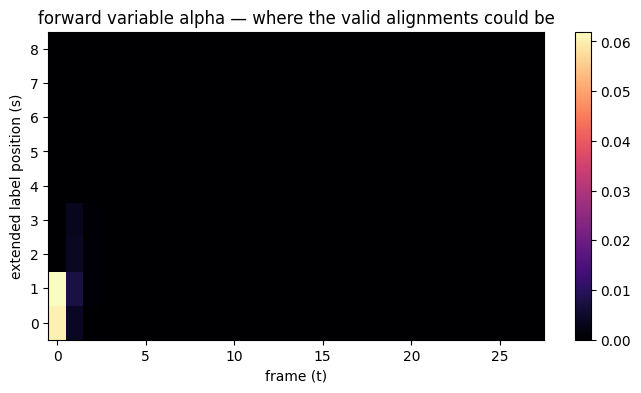

In [ ]:
example_label = file_labels[0][1]              # 'zero' — matches the wav/spec/probs already in memory
encoded_label = encode_label(example_label)

loss, alpha, extended_labels = ctc_loss(probs, encoded_label, blank_idx)

print('extended labels:', extended_labels)
print('total_prob (should be between 0 and 1):', np.exp(-loss))
print('loss:', loss)

plt.figure(figsize=(8, 4))
plt.imshow(alpha.T, aspect='auto', origin='lower', cmap='magma')
plt.xlabel('frame (t)')
plt.ylabel('extended label position (s)')
plt.title('forward variable alpha — where the valid alignments could be')
plt.colorbar()
plt.show()

In [ ]:
def logsumexp(*values):
    values = [v for v in values if v != -np.inf]
    if not values:
        return -np.inf
    m = max(values)
    return m + np.log(sum(np.exp(v - m) for v in values))

In [ ]:
def ctc_forward_log(log_probs, extended_labels, blank_idx):
    T = log_probs.shape[0]
    S = len(extended_labels)
    log_alpha = np.full((T, S), -np.inf)   # -inf represents log(0) — "impossible"

    log_alpha[0, 0] = log_probs[0, extended_labels[0]]
    if S > 1:
        log_alpha[0, 1] = log_probs[0, extended_labels[1]]

    for t in range(1, T):
        for s in range(S):
            candidates = [log_alpha[t-1, s]]                      # stay
            if s > 0:
                candidates.append(log_alpha[t-1, s-1])            # advance
            if s > 1 and extended_labels[s] != blank_idx and extended_labels[s] != extended_labels[s-2]:
                candidates.append(log_alpha[t-1, s-2])             # skip (only for two different letters)
            log_alpha[t, s] = logsumexp(*candidates) + log_probs[t, extended_labels[s]]

    if S > 1:
        total_log_prob = logsumexp(log_alpha[T-1, S-1], log_alpha[T-1, S-2])
    else:
        total_log_prob = log_alpha[T-1, S-1]

    return log_alpha, total_log_prob

def ctc_loss_log(probs, encoded_label, blank_idx):
    extended_labels = make_extended_labels(encoded_label, blank_idx)
    log_probs = np.log(probs + 1e-12)   # this epsilon is fine — it's just guarding a single log(0), not accumulating
    log_alpha, total_log_prob = ctc_forward_log(log_probs, extended_labels, blank_idx)
    loss = -total_log_prob
    return loss, log_alpha, extended_labels

loss: 62.059580319299016


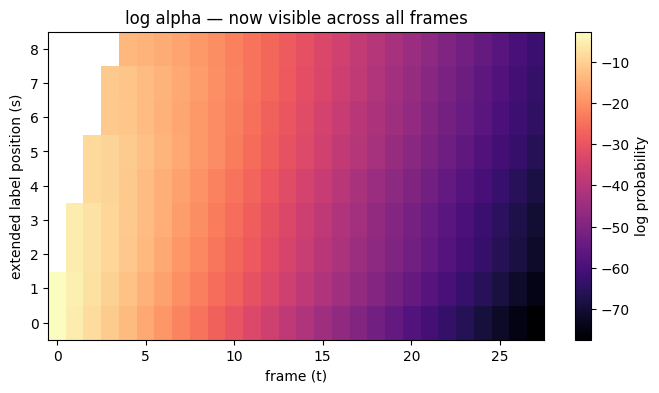

In [ ]:
loss, log_alpha, extended_labels = ctc_loss_log(probs, encoded_label, blank_idx)

print('loss:', loss)

plt.figure(figsize=(8, 4))
plt.imshow(log_alpha.T, aspect='auto', origin='lower', cmap='magma')
plt.xlabel('frame (t)')
plt.ylabel('extended label position (s)')
plt.title('log alpha — now visible across all frames')
plt.colorbar(label='log probability')
plt.show()

In [ ]:
def ctc_backward_log(log_probs, extended_labels, blank_idx):
    T = log_probs.shape[0]
    S = len(extended_labels)
    log_beta = np.full((T, S), -np.inf)

    log_beta[T-1, S-1] = log_probs[T-1, extended_labels[S-1]]
    if S > 1:
        log_beta[T-1, S-2] = log_probs[T-1, extended_labels[S-2]]

    for t in range(T-2, -1, -1):
        for s in range(S):
            candidates = [log_beta[t+1, s]]                    # stay
            if s < S - 1:
                candidates.append(log_beta[t+1, s+1])           # advance
            if s < S - 2 and extended_labels[s] != blank_idx and extended_labels[s+2] != extended_labels[s]:
                candidates.append(log_beta[t+1, s+2])            # skip (two different letters only)
            log_beta[t, s] = logsumexp(*candidates) + log_probs[t, extended_labels[s]]

    return log_beta

In [ ]:
def ctc_gradient(probs, encoded_label, blank_idx):
    extended_labels = make_extended_labels(encoded_label, blank_idx)
    log_probs = np.log(probs + 1e-12)

    log_alpha, total_log_prob = ctc_forward_log(log_probs, extended_labels, blank_idx)
    log_beta = ctc_backward_log(log_probs, extended_labels, blank_idx)

    T, vocab_size = probs.shape
    S = len(extended_labels)

    emission_log_probs = log_probs[:, extended_labels]              # (T, S)
    log_gamma = log_alpha + log_beta - emission_log_probs - total_log_prob
    gamma = np.exp(log_gamma)                                        # (T, S) posterior per position

    target_posterior = np.zeros((T, vocab_size))
    for s in range(S):
        target_posterior[:, extended_labels[s]] += gamma[:, s]

    grad_logits = probs - target_posterior                           # (T, vocab_size)
    loss = -total_log_prob
    return loss, grad_logits

In [ ]:
def rnn_forward(spec, params):
    T = spec.shape[0]
    hidden_dim = params['W_hh'].shape[0]
    h = np.zeros(hidden_dim)
    hidden_states = [h]
    logits = []
    for t in range(T):
        x_t = spec[t]
        h = np.tanh(params['W_xh'] @ x_t + params['W_hh'] @ h + params['b_h'])
        y_t = params['W_hy'] @ h + params['b_y']
        hidden_states.append(h)
        logits.append(y_t)
    logits = np.array(logits)
    probs = softmax(logits)
    return probs, logits, np.array(hidden_states)   # now also returns raw logits

probs, logits, hidden_states = rnn_forward(spec, params)

In [36]:
def loss_from_logits(logits, encoded_label, blank_idx):
    probs = softmax(logits)
    extended_labels = make_extended_labels(encoded_label, blank_idx)
    log_probs = np.log(probs + 1e-12)
    _, total_log_prob = ctc_forward_log(log_probs, extended_labels, blank_idx)
    return -total_log_prob

loss, grad_logits = ctc_gradient(probs, encoded_label, blank_idx)
print('loss (should match Phase 5 part 1):', loss)

rng = np.random.default_rng(0)
eps = 1e-4
for _ in range(5):
    t = rng.integers(0, logits.shape[0])
    k = rng.integers(0, logits.shape[1])

    logits_plus = logits.copy();  logits_plus[t, k]  += eps
    logits_minus = logits.copy(); logits_minus[t, k] -= eps

    numerical_grad = (loss_from_logits(logits_plus, encoded_label, blank_idx) -
                       loss_from_logits(logits_minus, encoded_label, blank_idx)) / (2 * eps)

    print(f't={t:2d}, k={k:2d}  analytical={grad_logits[t,k]: .6f}  numerical={numerical_grad: .6f}')

loss (should match Phase 5 part 1): 62.059580319299016
t=23, k=10  analytical= 0.070667  numerical= 0.070667
t=14, k= 4  analytical= 0.064077  numerical= 0.064077
t= 8, k= 0  analytical=-0.375146  numerical=-0.375146
t= 2, k= 0  analytical=-0.526532  numerical=-0.526532
t= 4, k=13  analytical= 0.055439  numerical= 0.055439


In [37]:
def rnn_backward(spec, hidden_states, grad_logits, params):
    T = spec.shape[0]
    hidden_dim = params['W_hh'].shape[0]

    grads = {k: np.zeros_like(v) for k, v in params.items()}
    dh_next = np.zeros(hidden_dim)   # nothing flows back from "after the last frame"

    for t in reversed(range(T)):
        dy = grad_logits[t]
        h_t = hidden_states[t + 1]      # state after processing frame t
        h_prev = hidden_states[t]       # state fed INTO frame t

        grads['W_hy'] += np.outer(dy, h_t)
        grads['b_y']  += dy

        dh = params['W_hy'].T @ dy + dh_next   # output path + future timestep path
        dtanh = (1 - h_t**2) * dh              # d/dz tanh(z) = 1 - tanh(z)^2

        grads['b_h']  += dtanh
        grads['W_xh'] += np.outer(dtanh, spec[t])
        grads['W_hh'] += np.outer(dtanh, h_prev)

        dh_next = params['W_hh'].T @ dtanh

    return grads

In [38]:
def loss_from_params(spec, encoded_label, params, blank_idx):
    probs, logits, _ = rnn_forward(spec, params)
    return loss_from_logits(logits, encoded_label, blank_idx)

def check_param_grad(name, spec, encoded_label, params, blank_idx, n=3, eps=1e-4):
    probs, logits, hidden_states = rnn_forward(spec, params)
    _, grad_logits = ctc_gradient(probs, encoded_label, blank_idx)
    grads = rnn_backward(spec, hidden_states, grad_logits, params)

    rng = np.random.default_rng(1)
    for _ in range(n):
        idx = tuple(rng.integers(0, s) for s in params[name].shape)
        orig = params[name][idx]

        params[name][idx] = orig + eps
        loss_plus = loss_from_params(spec, encoded_label, params, blank_idx)
        params[name][idx] = orig - eps
        loss_minus = loss_from_params(spec, encoded_label, params, blank_idx)
        params[name][idx] = orig

        numerical = (loss_plus - loss_minus) / (2 * eps)
        print(f'{name}{idx}  analytical={grads[name][idx]: .6f}  numerical={numerical: .6f}')

for name in params:
    check_param_grad(name, spec, encoded_label, params, blank_idx)

W_xh(np.int64(30), np.int64(51))  analytical= 0.699379  numerical= 0.699379
W_xh(np.int64(48), np.int64(95))  analytical=-0.028179  numerical=-0.028179
W_xh(np.int64(2), np.int64(14))  analytical=-0.061448  numerical=-0.061448
W_hh(np.int64(30), np.int64(32))  analytical=-0.095607  numerical=-0.095607
W_hh(np.int64(48), np.int64(60))  analytical= 0.597553  numerical= 0.597553
W_hh(np.int64(2), np.int64(9))  analytical= 0.060427  numerical= 0.060427
b_h(np.int64(30),)  analytical= 1.512007  numerical= 1.512007
b_h(np.int64(32),)  analytical= 0.537744  numerical= 0.537744
b_h(np.int64(48),)  analytical=-1.217380  numerical=-1.217380
W_hy(np.int64(7), np.int64(32))  analytical= 0.390822  numerical= 0.390822
W_hy(np.int64(12), np.int64(60))  analytical=-0.859689  numerical=-0.859689
W_hy(np.int64(0), np.int64(9))  analytical= 0.732075  numerical= 0.732075
b_y(np.int64(7),)  analytical=-1.402858  numerical=-1.402859
b_y(np.int64(8),)  analytical=-3.039950  numerical=-3.039950
b_y(np.int64(1

In [39]:
def clip_grads(grads, max_norm=5.0):
    total_norm = np.sqrt(sum(np.sum(g**2) for g in grads.values()))
    if total_norm > max_norm:
        for k in grads:
            grads[k] *= max_norm / (total_norm + 1e-8)

def train_epoch(data, params, blank_idx, lr=0.05):
    total_loss = 0.0
    for i in np.random.permutation(len(data)):
        waveform, label = data[i]
        spec = compute_spectrogram(waveform, sr)
        encoded = encode_label(label)

        probs, logits, hidden_states = rnn_forward(spec, params)
        loss, grad_logits = ctc_gradient(probs, encoded, blank_idx)
        grads = rnn_backward(spec, hidden_states, grad_logits, params)
        clip_grads(grads)

        for k in params:
            params[k] -= lr * grads[k]
        total_loss += loss
    return total_loss / len(data)

params = init_rnn_params(input_dim, hidden_dim, vocab_size)
for epoch in range(15):
    avg = train_epoch(train_set, params, blank_idx)
    print(f'epoch {epoch+1}: avg loss = {avg:.3f}')

epoch 1: avg loss = 8.851
epoch 2: avg loss = 6.628
epoch 3: avg loss = 6.229
epoch 4: avg loss = 5.946
epoch 5: avg loss = 5.424
epoch 6: avg loss = 5.286
epoch 7: avg loss = 5.080
epoch 8: avg loss = 4.966
epoch 9: avg loss = 4.815
epoch 10: avg loss = 4.915
epoch 11: avg loss = 4.751
epoch 12: avg loss = 4.483
epoch 13: avg loss = 4.424
epoch 14: avg loss = 4.478
epoch 15: avg loss = 4.314


In [40]:
def greedy_decode(probs, idx_to_char, blank_idx):
    path = np.argmax(probs, axis=1)
    collapsed, prev = [], None
    for i in path:
        if i != prev:
            collapsed.append(i)
        prev = i
    return ''.join(idx_to_char[i] for i in collapsed if i != blank_idx)

def evaluate(data, params, blank_idx):
    correct = 0
    for waveform, label in data:
        probs, _, _ = rnn_forward(compute_spectrogram(waveform, sr), params)
        if greedy_decode(probs, idx_to_char, blank_idx) == label:
            correct += 1
    return correct / len(data)

print('test accuracy:', evaluate(test_set, params, blank_idx))

test accuracy: 0.365


In [41]:
from collections import Counter

def confusion(data, params, blank_idx):
    conf = Counter()
    for waveform, label in data:
        probs, _, _ = rnn_forward(compute_spectrogram(waveform, sr), params)
        pred = greedy_decode(probs, idx_to_char, blank_idx)
        conf[(label, pred)] += 1
    return conf

conf = confusion(test_set, params, blank_idx)
for (true, pred), n in sorted(conf.items(), key=lambda x: -x[1]):
    if true != pred:
        print(f'{true:>6} -> {pred!r:<12} x{n}')

  zero -> 'nero'       x11
   six -> 'feur'       x9
  five -> 'feur'       x9
  four -> 'feur'       x7
 eight -> 'feur'       x7
  five -> 'four'       x7
  nine -> 'feur'       x7
  four -> 'fiur'       x6
 seven -> 'feur'       x6
   one -> 'feur'       x6
 three -> 'feur'       x5
 three -> 'four'       x5
  zero -> 'tero'       x5
  nine -> 'nero'       x5
   one -> 'four'       x5
   two -> 'feu'        x5
  zero -> 'niro'       x5
  nine -> 'niro'       x5
  five -> 'fiur'       x4
  four -> 'fourn'      x4
 seven -> 'seve'       x4
   two -> 'feur'       x4
 three -> 'feure'      x4
  zero -> 'feur'       x4
   six -> 'siven'      x3
 seven -> 'sive'       x3
   one -> 'our'        x3
   one -> 'tone'       x3
   six -> 'fiur'       x3
   two -> 'six'        x3
   two -> 'sour'       x3
   six -> 'tix'        x3
 seven -> 'six'        x3
   one -> 'nine'       x3
 seven -> 'fiur'       x3
 three -> 'thre'       x3
 seven -> 'fourn'      x2
 seven -> 'sivee'      x2
  four -> '

In [42]:
def edit_distance(a, b):
    dp = [[0]*(len(b)+1) for _ in range(len(a)+1)]
    for i in range(len(a)+1): dp[i][0] = i
    for j in range(len(b)+1): dp[0][j] = j
    for i in range(1, len(a)+1):
        for j in range(1, len(b)+1):
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1, dp[i-1][j-1]+cost)
    return dp[-1][-1]

def avg_cer(data, params, blank_idx):
    total_dist, total_chars = 0, 0
    for waveform, label in data:
        probs, _, _ = rnn_forward(compute_spectrogram(waveform, sr), params)
        pred = greedy_decode(probs, idx_to_char, blank_idx)
        total_dist += edit_distance(pred, label)
        total_chars += len(label)
    return total_dist / total_chars

print('CER:', avg_cer(test_set, params, blank_idx))

CER: 0.45691797845898924


In [46]:
def compute_norm_stats(dataset, sr):
    all_specs = [compute_spectrogram(w, sr) for w, _ in dataset]
    stacked = np.concatenate(all_specs, axis=0)   # (total_frames, freq_bins)
    return stacked.mean(axis=0), stacked.std(axis=0) + 1e-8

mean, std = compute_norm_stats(train_set, sr)

def compute_spectrogram_norm(waveform, sr):
    spec = compute_spectrogram(waveform, sr)
    return (spec - mean) / std

In [43]:
params = init_rnn_params(input_dim, hidden_dim, vocab_size)
lr = 0.05
for epoch in range(50):
    if epoch > 0 and epoch % 10 == 0:
        lr *= 0.5
    avg = train_epoch(train_set, params, blank_idx, lr=lr)
    print(f'epoch {epoch+1}: loss={avg:.3f}  lr={lr:.4f}')
    if (epoch+1) % 5 == 0:
        print('  CER:', avg_cer(test_set, params, blank_idx))

epoch 1: loss=8.346  lr=0.0500
epoch 2: loss=6.704  lr=0.0500
epoch 3: loss=7.108  lr=0.0500
epoch 4: loss=5.830  lr=0.0500
epoch 5: loss=5.403  lr=0.0500
  CER: 0.4776304888152444
epoch 6: loss=5.200  lr=0.0500
epoch 7: loss=5.256  lr=0.0500
epoch 8: loss=4.867  lr=0.0500
epoch 9: loss=4.738  lr=0.0500
epoch 10: loss=4.689  lr=0.0500
  CER: 0.39353769676884837
epoch 11: loss=3.950  lr=0.0250
epoch 12: loss=3.907  lr=0.0250
epoch 13: loss=3.865  lr=0.0250
epoch 14: loss=3.800  lr=0.0250
epoch 15: loss=3.728  lr=0.0250
  CER: 0.36909693454846726
epoch 16: loss=3.723  lr=0.0250
epoch 17: loss=3.660  lr=0.0250
epoch 18: loss=3.617  lr=0.0250
epoch 19: loss=3.614  lr=0.0250
epoch 20: loss=3.529  lr=0.0250
  CER: 0.3724109362054681
epoch 21: loss=3.251  lr=0.0125
epoch 22: loss=3.188  lr=0.0125
epoch 23: loss=3.203  lr=0.0125
epoch 24: loss=3.182  lr=0.0125
epoch 25: loss=3.136  lr=0.0125
  CER: 0.3492129246064623
epoch 26: loss=3.096  lr=0.0125
epoch 27: loss=3.084  lr=0.0125
epoch 28: los